In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/ecommerce_sales_data.csv")

In [3]:
print("Dataset loaded successfully.")
print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])

Dataset loaded successfully.
Rows:  50000
Columns:  10


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,508484,P1003,Smart Watch,Fashion,3,2025-01-01 08:01:00,106.16,12319.0,Germany,318.48
1,525117,P1067,Notebook,Home & Kitchen,3,2025-01-01 08:15:00,31.01,11072.0,India,93.03
2,514170,P1030,Bluetooth Speaker,Fashion,2,2025-01-01 08:15:00,52.96,12115.0,Italy,105.92
3,518353,P1070,Yoga Mat,Beauty,2,2025-01-01 08:16:00,67.56,11224.0,Canada,135.12
4,509886,P1096,Pen Set,Beauty,4,2025-01-01 08:29:00,74.16,11000.0,Canada,296.64


In [5]:
df.tail()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
49995,519905,P1052,Bedsheet,Home & Kitchen,4,2026-08-15 21:34:00,22.63,11512.0,India,90.52
49996,515740,P1007,Wireless Mouse,Books,-3,2026-08-15 21:40:00,11.63,10103.0,United Kingdom,-34.89
49997,517122,P1098,Yoga Mat,Books,3,2026-08-15 21:42:00,6.39,10878.0,India,19.17
49998,502839,P1049,Cookware Set,Electronics,2,2026-08-15 21:42:00,54.67,10163.0,India,109.34
49999,511203,P1073,Face Wash,Home & Kitchen,5,2026-08-15 21:59:00,78.66,11526.0,France,393.30


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    50000 non-null  object 
 1   StockCode    50000 non-null  object 
 2   Description  49817 non-null  object 
 3   Category     50000 non-null  object 
 4   Quantity     50000 non-null  int64  
 5   InvoiceDate  50000 non-null  object 
 6   UnitPrice    50000 non-null  float64
 7   CustomerID   49279 non-null  float64
 8   Country      50000 non-null  object 
 9   Revenue      50000 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 3.8+ MB


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,183
Category,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,721
Country,0
Revenue,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [10]:
df = df.dropna(subset=["CustomerID"])

In [11]:
df["CustomerID"].isnull().sum()

np.int64(0)

In [12]:
df["Description"] = df["Description"].fillna("Unknown Product")

In [13]:
df["Description"].isnull().sum()

np.int64(0)

In [14]:
(df["Quantity"] <= 0).sum()

np.int64(936)

In [15]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

df["IsCancelled"] = df["InvoiceNo"].str.startswith("C")

In [16]:
df["IsCancelled"].value_counts()

,count
IsCancelled,
False,48833
True,446


In [17]:
sales_df = df[(df["IsCancelled"] == False) &(df["Quantity"] > 0) &(df["UnitPrice"] > 0)].copy()

In [18]:
sales_df.shape

(48294, 11)

In [19]:
sales_df["Revenue"] = (sales_df["Quantity"] * sales_df["UnitPrice"]).round(2)

In [20]:
sales_df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,3,106.16,318.48
1,3,31.01,93.03
2,2,52.96,105.92
3,2,67.56,135.12
4,4,74.16,296.64


In [21]:
print("Rows:", len(sales_df))
print("Columns:", len(sales_df.columns))
print("Missing CustomerID:", sales_df["CustomerID"].isnull().sum())
print("Missing Description:", sales_df["Description"].isnull().sum())
print("Duplicate Rows:", sales_df.duplicated().sum())
print("Negative Quantity:", (sales_df["Quantity"] < 0).sum())
print("Zero Quantity:", (sales_df["Quantity"] == 0).sum())
print("Invalid Price:", (sales_df["UnitPrice"] <= 0).sum())
print("Cancelled Invoices:", sales_df["IsCancelled"].sum())

Rows: 48294
Columns: 11
Missing CustomerID: 0
Missing Description: 0
Duplicate Rows: 0
Negative Quantity: 0
Zero Quantity: 0
Invalid Price: 0
Cancelled Invoices: 0


In [22]:
sales_df = sales_df.drop(columns=["IsCancelled"])

In [23]:
sales_df.shape

(48294, 10)

In [24]:
sales_df.to_csv("ecommerce_sales_cleaned.csv", index=False)

In [25]:
import os

os.path.exists("ecommerce_sales_cleaned.csv")

True

In [26]:
sales_df.to_csv("ecommerce_sales_cleaned.csv", index=False)

In [27]:
# Business KPIs

total_revenue = sales_df["Revenue"].sum()
total_orders = sales_df["InvoiceNo"].nunique()
total_customers = sales_df["CustomerID"].nunique()
total_quantity = sales_df["Quantity"].sum()
average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 9624637.48
Total Orders: 30791
Total Customers: 2488
Total Quantity Sold: 154741
Average Order Value: 312.58


In [28]:
#     Customer Repeat Behaviour
orders_per_customer = (sales_df.groupby("CustomerID")["InvoiceNo"]
                       .nunique())

repeat_customers = (orders_per_customer > 1).sum()

repeat_customer_rate = (repeat_customers / total_customers) * 100

print("Repeat Customers:", repeat_customers)
print("Repeat Customer Rate:", round(repeat_customer_rate, 2), "%")

Repeat Customers: 2467
Repeat Customer Rate: 99.16 %


In [29]:
# Customer Repeat Behaviour

orders_per_customer = (sales_df.groupby("CustomerID")["InvoiceNo"].nunique())

repeat_customers = (orders_per_customer > 1).sum()
one_time_customers = (orders_per_customer == 1).sum()

repeat_data = pd.DataFrame({
    "Customer Type": ["Repeat Customers", "One-Time Customers"],
    "Customer Count": [repeat_customers, one_time_customers]
})

repeat_data

,Customer Type,Customer Count
0,Repeat Customers,2467
1,One-Time Customers,21


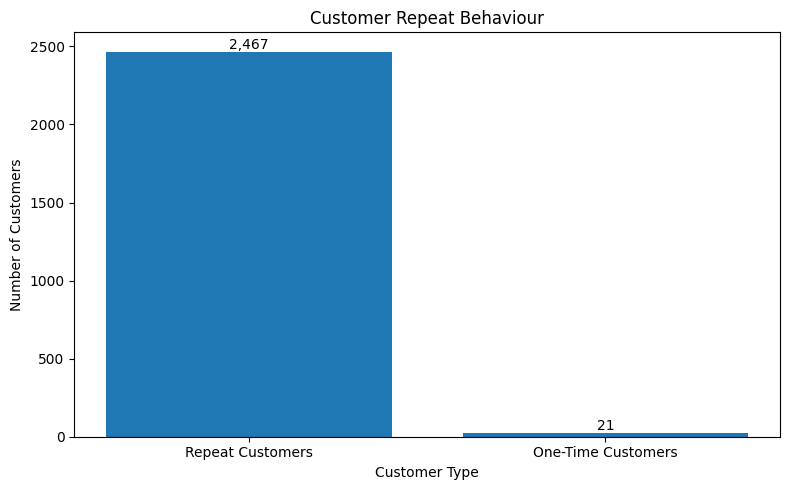

In [30]:
# Chart-Customer Repeat Behaviour

plt.figure(figsize=(8, 5))

bars = plt.bar(
    repeat_data["Customer Type"],
    repeat_data["Customer Count"]
)

plt.title("Customer Repeat Behaviour")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

# Show values on bars
for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,value,f"{int(value):,}"
    ,ha="center",va="bottom",fontsize=10)

plt.tight_layout()
plt.show()

In [34]:
# Top 10 Customers by Revenue

top_10_customers = (
    sales_df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_customers

,Revenue
CustomerID,
12167.0,32882.43
10847.0,32168.73
10249.0,31038.85
10140.0,28597.92
12143.0,27924.21
12446.0,27811.78
11770.0,27129.70
12365.0,26828.39
12297.0,25426.45


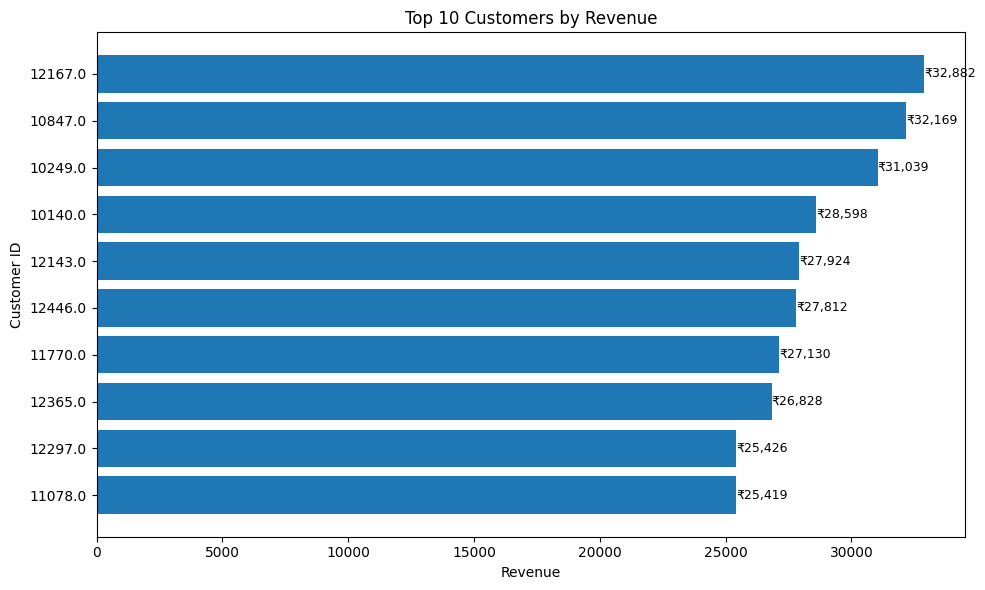

In [35]:
#   Chart-customer revenue

plt.figure(figsize=(10, 6))

bars = plt.barh(top_10_customers.index.astype(str),top_10_customers.values)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

# Highest revenue
plt.gca().invert_yaxis()

# revenue values
for bar in bars:
    value = bar.get_width()
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"₹{value:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [36]:
#    Product performance
product_revenue = (sales_df.groupby("Description")["Revenue"]
                   .sum().sort_values(ascending=False))

product_revenue.head(10)

,Revenue
Description,
Wireless Headphones,608258.12
Keyboard,480721.90
Coffee Mug,467636.04
Smart Watch,453360.16
T-Shirt,439025.71
Novel,435033.32
Building Blocks,429530.17
Pen Set,405878.82
Bluetooth Speaker,379418.10


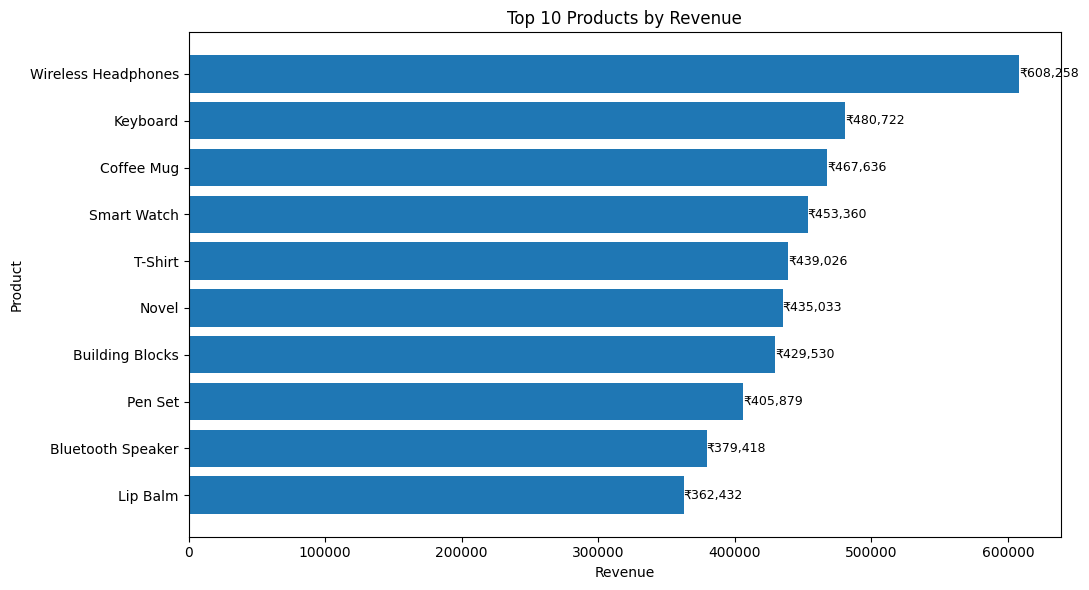

In [37]:

top_10_products = product_revenue.head(10)

plt.figure(figsize=(11, 6))

bars = plt.barh(top_10_products.index, top_10_products.values)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

# Highest revenue product
plt.gca().invert_yaxis()

# show revenue values
for bar in bars:
    value = bar.get_width()
    plt.text(value,bar.get_y() + bar.get_height() / 2,f"₹{value:,.0f}",va="center",fontsize=9)

plt.tight_layout()
plt.show()

In [38]:
# Monthly Revenue Analysis

sales_df["YearMonth"] = sales_df["InvoiceDate"].dt.to_period("M")

monthly_revenue = (sales_df.groupby("YearMonth")["Revenue"].sum()
.reset_index())

monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)

monthly_revenue

,YearMonth,Revenue
0,2025-01,519777.59
1,2025-02,436398.88
2,2025-03,508908.25
3,2025-04,490082.38
4,2025-05,517966.55
5,2025-06,492566.05
6,2025-07,505719.02
7,2025-08,475577.29
8,2025-09,474885.30
9,2025-10,510036.18


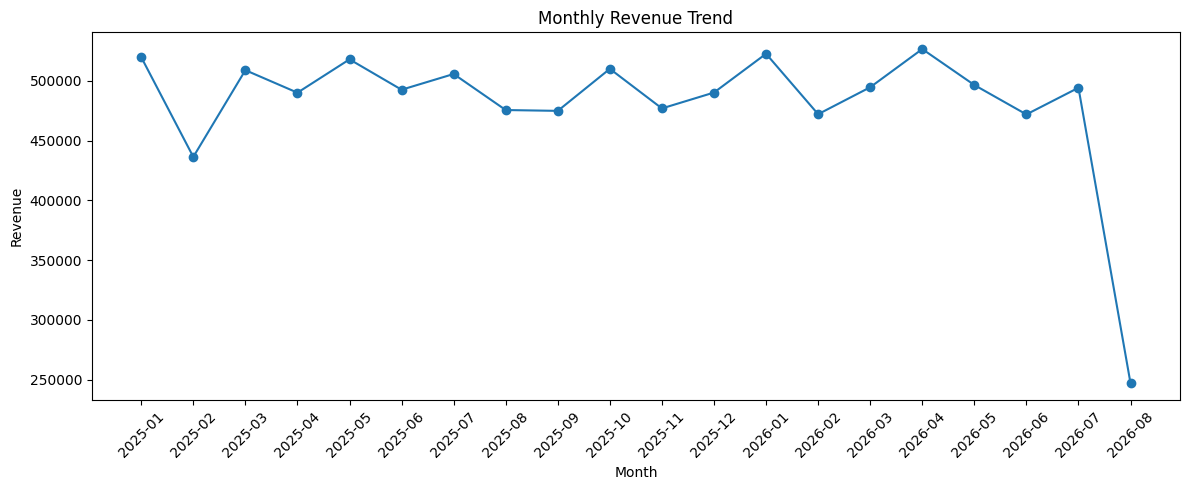

In [39]:
# Monthly sales analysis
sales_df["YearMonth"] = sales_df["InvoiceDate"].dt.to_period("M")

monthly_revenue = (
    sales_df.groupby("YearMonth")["Revenue"].sum().reset_index())

monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["YearMonth"],monthly_revenue["Revenue"],marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
# Country Analysis
country_revenue = (sales_df.groupby("Country")["Revenue"].sum()
    .sort_values(ascending=False)
)
top_10_countries = country_revenue.head(10)
top_10_countries

,Revenue
Country,
India,3241534.06
United Kingdom,2111534.36
Germany,891684.16
France,782672.20
Netherlands,564991.27
Australia,506636.26
United States,478448.75
Canada,379568.64
Spain,368707.08


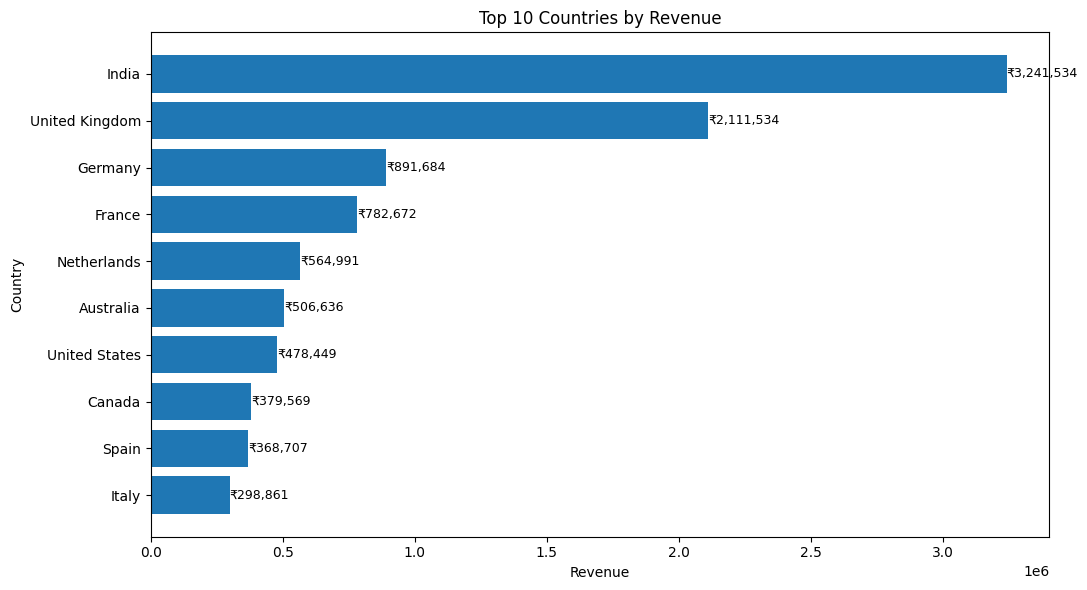

In [41]:
#Country-wise analysis

plt.figure(figsize=(11, 6))

bars = plt.barh(top_10_countries.index, top_10_countries.values)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.gca().invert_yaxis()

for bar in bars:
    value = bar.get_width()
    plt.text(value, bar.get_y() + bar.get_height() / 2, f"₹{value:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [42]:
#RFM reference date
reference_date = sales_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2026-08-16 21:59:00


In [43]:
rfm = (sales_df.groupby("CustomerID")
      .agg(
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    ).reset_index()
)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,10001.0,45,20,4211.62
1,10002.0,142,8,2583.94
2,10003.0,42,21,3572.01
3,10004.0,13,27,5737.28
4,10005.0,14,7,1220.71
5,10006.0,148,3,706.81
6,10007.0,77,15,2800.25
7,10008.0,82,11,1059.49
8,10009.0,21,7,1308.94
9,10010.0,82,12,2408.82


In [44]:
#Recency scores
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1], duplicates="drop")

#frequency scores
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])

# Monetary scores
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5], duplicates="drop")

In [45]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int).astype(str) +
    rfm["F_Score"].astype(int).astype(str) +
    rfm["M_Score"].astype(int).astype(str)
)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,10001.0,45,20,4211.62,2,4,4,244
1,10002.0,142,8,2583.94,1,2,3,123
2,10003.0,42,21,3572.01,2,4,4,244
3,10004.0,13,27,5737.28,4,4,5,445
4,10005.0,14,7,1220.71,4,1,1,411
5,10006.0,148,3,706.81,1,1,1,111
6,10007.0,77,15,2800.25,2,3,3,233
7,10008.0,82,11,1059.49,1,2,1,121
8,10009.0,21,7,1308.94,3,1,2,312
9,10010.0,82,12,2408.82,1,2,3,123


In [46]:
def segment_customer(row):
    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 4:
        return "Loyal Customers"
    elif r >= 4 and m >= 4:
        return "Big Spenders"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost Customers"
    else:
        return "Potential Loyalists"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [47]:
segment_distribution = (rfm["Segment"].value_counts().reset_index())
segment_distribution.columns = ["Segment", "Customers"]
segment_distribution

,Segment,Customers
0,Potential Loyalists,685
1,Lost Customers,609
2,Champions,581
3,At Risk,318
4,Loyal Customers,252
5,Big Spenders,43


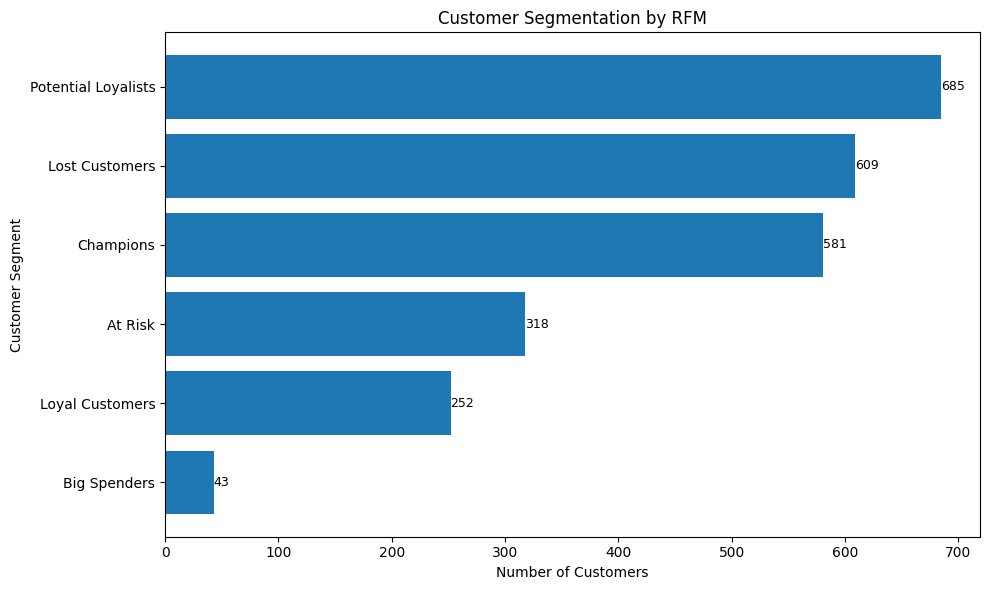

In [48]:
#RFM Segmentation chart
plt.figure(figsize=(10, 6))
bars = plt.barh(segment_distribution["Segment"], segment_distribution["Customers"])

plt.title("Customer Segmentation by RFM")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.gca().invert_yaxis()

for bar in bars:
    value = bar.get_width()
    plt.text(value,bar.get_y() + bar.get_height() / 2,f"{int(value):,}",va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [49]:
#Segment revenue
segment_revenue = (rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False))
segment_revenue

,Monetary
Segment,
Champions,4798458.66
Potential Loyalists,1471930.76
Loyal Customers,1287287.53
At Risk,1207936.91
Lost Customers,691145.95
Big Spenders,167877.67


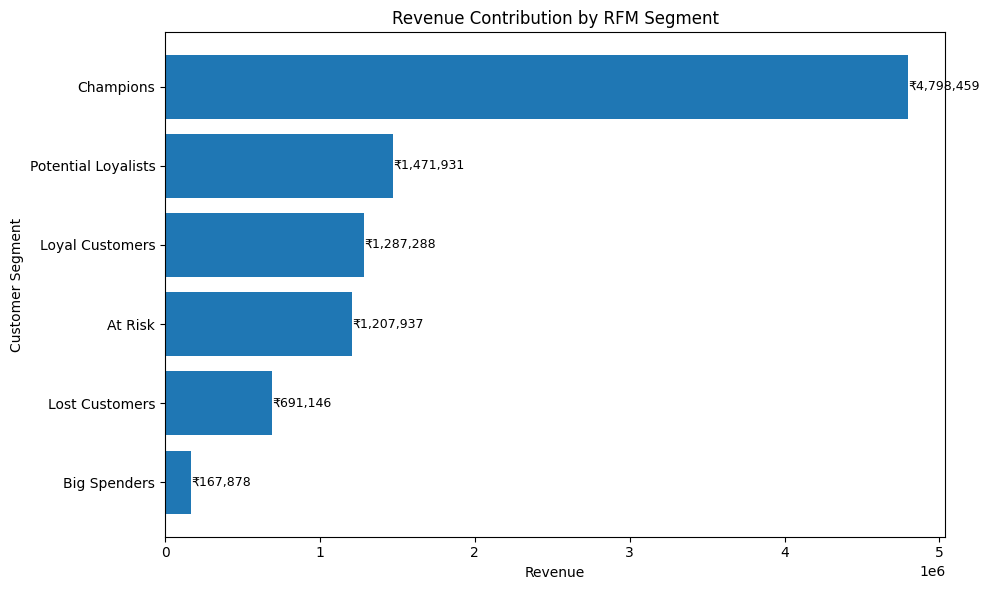

In [50]:
#Segment revenue chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    segment_revenue.index,
    segment_revenue.values
)
plt.title("Revenue Contribution by RFM Segment")
plt.xlabel("Revenue")
plt.ylabel("Customer Segment")

plt.gca().invert_yaxis()

for bar in bars:
    value = bar.get_width()
    plt.text(value,bar.get_y() + bar.get_height() / 2,f"₹{value:,.0f}",va="center",fontsize=9)

plt.tight_layout()
plt.show()

In [51]:
sales_df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Category',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country',
 'Revenue',
 'YearMonth']

In [52]:
rfm.to_csv("RFM_Analysis.csv", index=False)